# Simulation Study

In this Jupyter Notebook, the simulation study of the Masterthesis "Regression for Large Matrices with Joint Column and Row Reduction is performed.
Therefore, the following steps are covered:
- Importing required packages and functions
- Data Loading
- Application of Scoring Mechanisms such as Leverage Scores, Cross Leverage Scores, Random Scores and combined Scores
- Application of Column Reduction
- Application of Row Reduction
- Regression using linear models
- Evaluation of models and scoring mechanisms

In [147]:
#==============================================================================================
# Packages: Import of required packages for the simulation study
#==============================================================================================
%load_ext autoreload
%autoreload 2

import pandas as pd
from pathlib import Path
import random
from functions import get_leverage_scores, get_cross_leverage_scores, get_random_scores, get_combined_scores, \
    row_reduction, column_reduction
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from plotnine import ggplot, aes, geom_histogram, theme_bw, labs, geom_line, theme_minimal
from IPython.display import display

base = Path("/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data")
folder = "p1000_n900"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [148]:
#==============================================================================================
# Data Loading: Import the simulated data sets from corresponding folders
#==============================================================================================

## initialize lists to store data
df_train = []
df_test = []
y_train = []
y_test = []

## read in the simulation data
for i in range(10):
    df_train.append(
        pd.read_csv(f"{base}/{folder}/rep{i+1}/X_train.csv")
    )
    df_test.append(
        pd.read_csv(f"{base}/{folder}/rep{i+1}/X_test.csv")
    )
    y_train.append(
        pd.read_csv(f"{base}/{folder}/rep{i+1}/y_train.csv")
    )
    y_test.append(
        pd.read_csv(f"{base}/{folder}/rep{i+1}/y_test.csv")
    )

print("Shape of Training Data: ", np.shape(df_train[0]))
df_train[0].head()

Shape of Training Data:  (720, 1000)


,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,0.48940763,-1.3365464,-1.1138309,-0.4529517,1.6798241,-1.0300092,2.4265904,0.036485665,-0.9186341,-1.138299,...,1.0622252,0.27532765,0.78732353,0.17963603,-1.0355898,-0.019407177,-0.7403436,-1.9321772,1.1586596,-0.39525935
1,-0.95737004,0.045942705,-0.772199,1.0898916,-1.5788925,-0.95179075,-0.30889553,0.9685488,1.6352783,0.14434673,...,0.9248747,1.2113984,-1.2162019,-0.00029110722,1.9223812,-0.98204535,-1.3869884,-1.4774071,0.031359687,-0.13555853
2,-1.6415124,-2.3851411,1.4885222,-0.5683536,0.6096026,-0.3897477,1.7956898,-2.2578754,-0.4421387,0.15759848,...,-0.19137459,0.46999124,-1.6077456,0.72388417,-0.82483006,-0.7092231,-0.32290763,1.1495969,-0.968917,-0.16925187
3,0.9733367,-0.24864665,1.1663989,-0.9174811,0.9850009,-0.25291964,1.6127403,-1.3349732,-0.12970851,0.8061096,...,-1.0790758,0.0062031955,-0.114922,0.95770645,1.0548818,0.44111162,-0.304699,0.80287564,-1.439379,-1.5027109
4,0.58487713,-2.3099463,-0.095216036,-0.24510498,-0.9888419,1.0235603,0.6145533,0.027057976,-0.5657045,-1.6955075,...,1.3870474,1.6727191,-0.42102033,0.4229156,0.4812275,0.6687485,0.037214383,0.37430185,0.09666948,-1.3065377


In [149]:
#==============================================================================================
# Parameter Setting: Set the rank parameter and the seed of the script for reproducibility
#==============================================================================================

## set the seed
random.seed(1)

## set the basis parameters
k = 50
c = np.ceil(k * np.log(k))
r = np.ceil(c * np.log(c))

print("c = ", c)
print("r = ", r)

c =  196.0
r =  1035.0


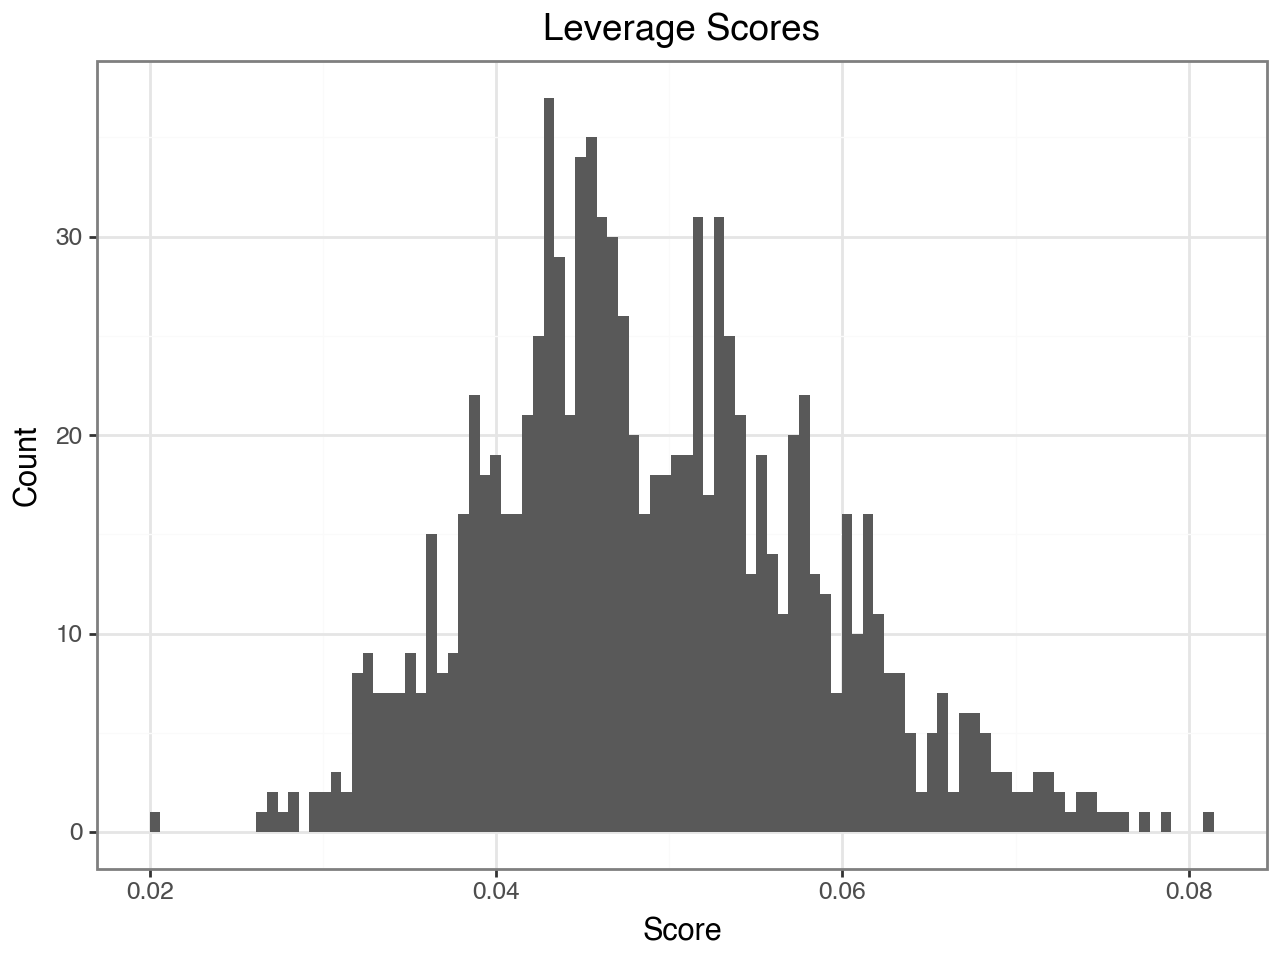

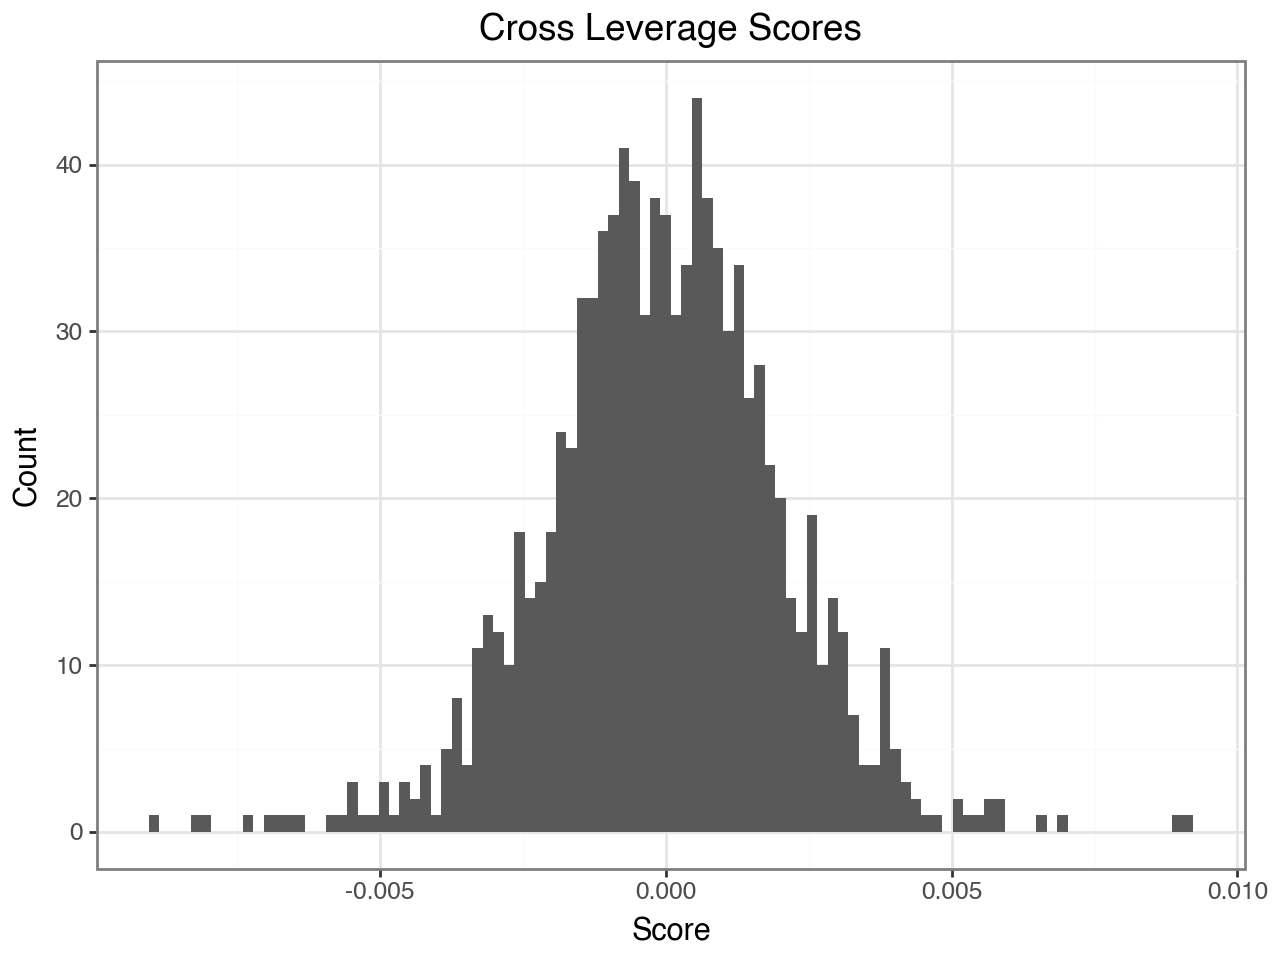

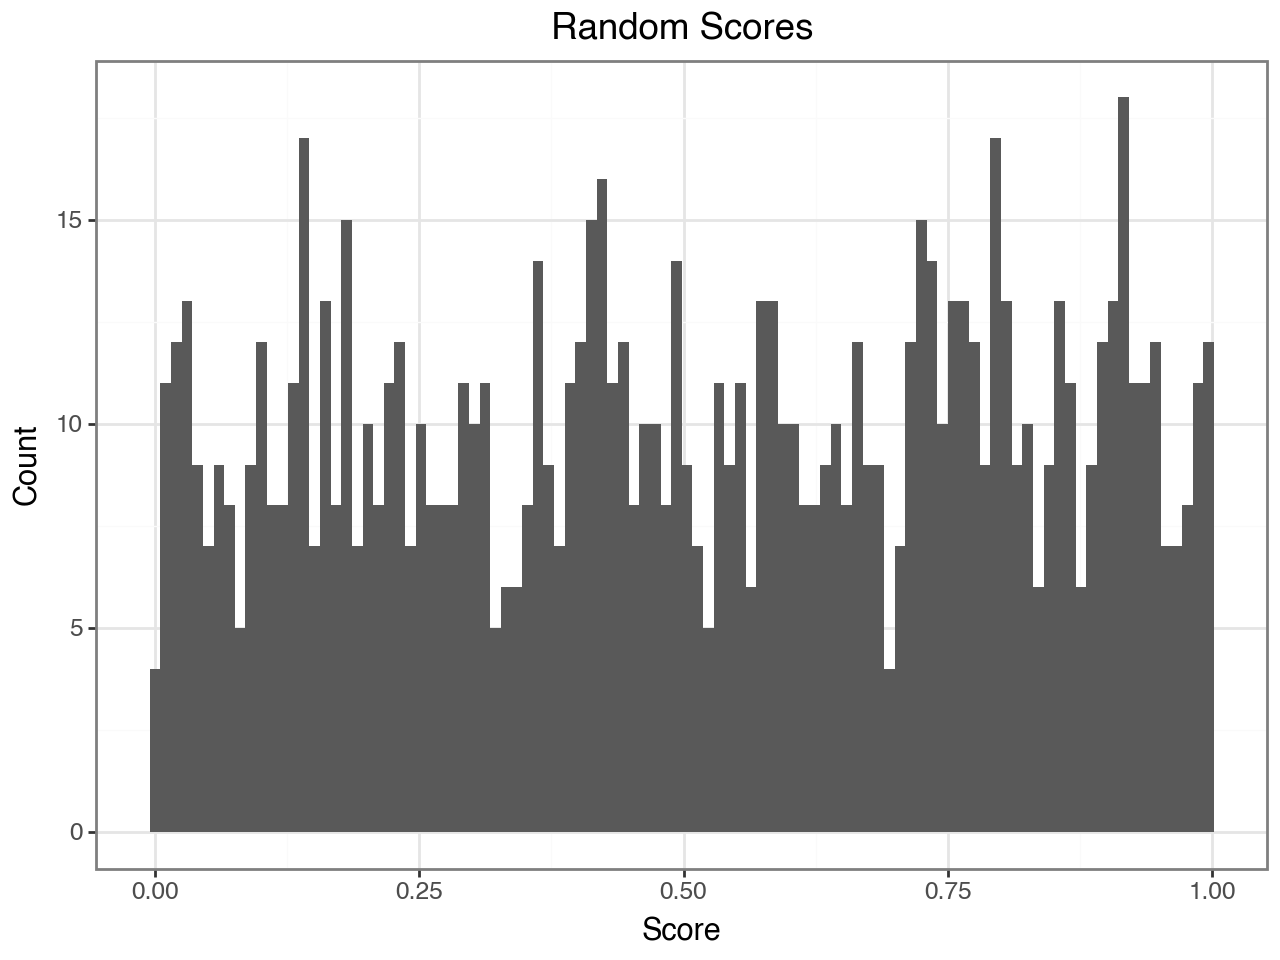

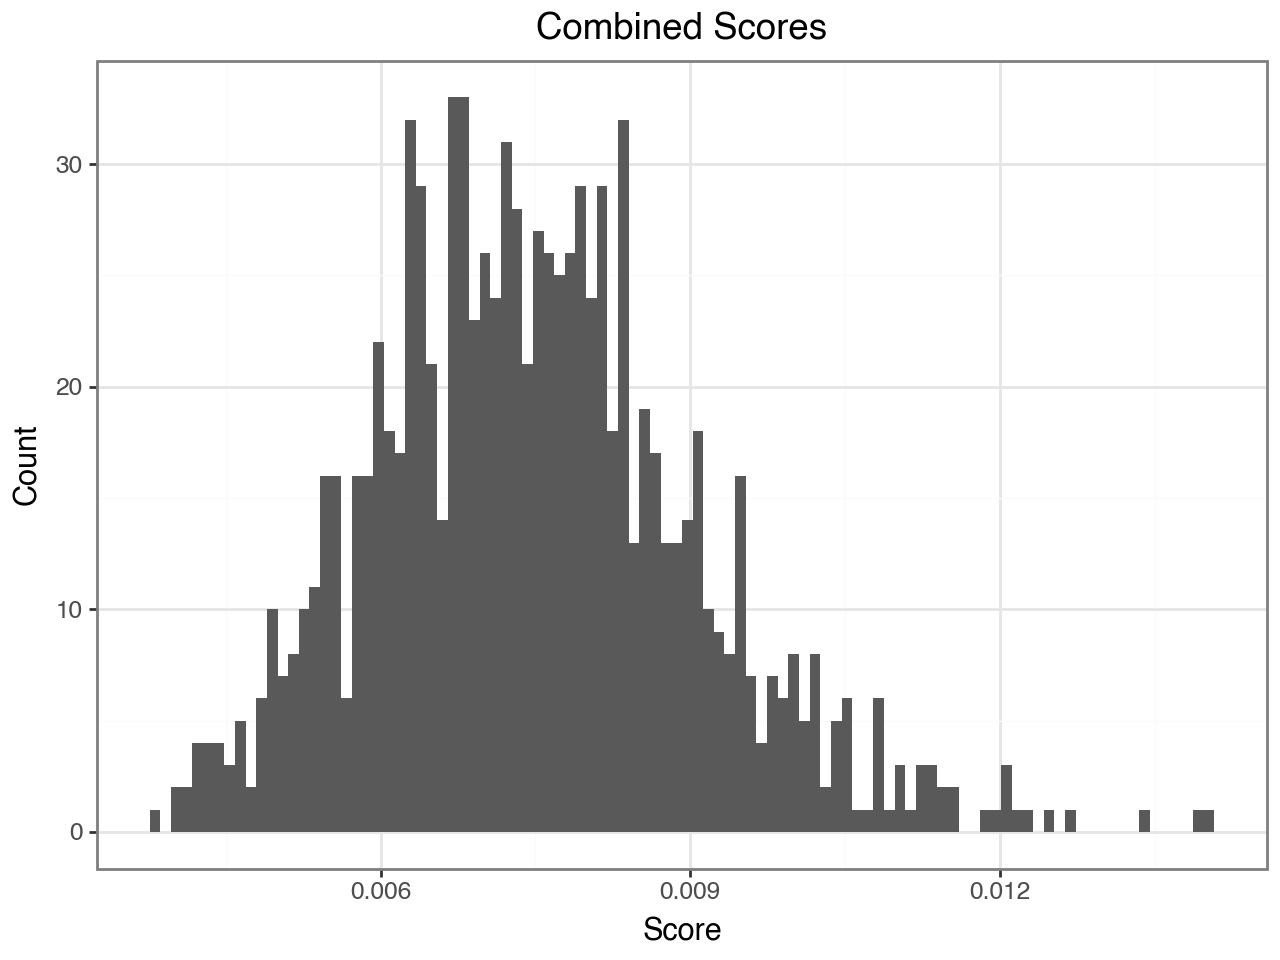

In [150]:
#==============================================================================================
# Scoring Mechanisms: Application of different scoring functions to the training data
#==============================================================================================

## Calculate the scores per data frame
column_ls = []
column_cls = []
column_rs = []
column_cs = []

for i in range(10):
    column_ls.append(get_leverage_scores(df_train[i], k))
    column_cls.append(get_cross_leverage_scores(df_train[i], y_train[i]))
    column_rs.append(get_random_scores(df_train[i]))
    column_cs.append(get_combined_scores(df_train[i], y_train[i], k, p_leverage = 0.2))

## Investigation of distributions
df_ls  = pd.DataFrame({'value': column_ls[0]})
df_cls = pd.DataFrame({'value': column_cls[0]})
df_rs  = pd.DataFrame({'value': column_rs[0]})
df_cs  = pd.DataFrame({'value': column_cs[0]})

display(
    ggplot(df_ls, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Leverage Scores', x='Score', y='Count')
)

display(
    ggplot(df_cls, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Cross Leverage Scores', x='Score', y='Count')
)

display(
    ggplot(df_rs, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Random Scores', x='Score', y='Count')
)

display(
    ggplot(df_cs, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Combined Scores', x='Score', y='Count')
)

In [162]:
#==============================================================================================
# Column Reduction: Application of column reduction mechanism
#==============================================================================================

## Calculation of column reduction
C_ls = []
C_cls = []
C_rs = []
C_cs = []

for i in range(10):
    C_ls.append(column_reduction(df_train[i], column_ls[i], k))
    C_cls.append(column_reduction(df_train[i], np.abs(column_cls[i]), k))
    C_rs.append(column_reduction(df_train[i], column_rs[i], k))
    C_cs.append(column_reduction(df_train[i], column_cs[i], k))

In [163]:
#==============================================================================================
# Row Reduction: Application of row reduction mechanism
#==============================================================================================

## Calculation of row reduction
R_ls = []
R_cls = []
R_rs = []
R_cs = []

for i in range(10):
    R_ls.append(row_reduction(C_ls[i]['C'], y_train[i], k))
    R_cls.append(row_reduction(C_cls[i]['C'], y_train[i], k))
    R_rs.append(row_reduction(C_rs[i]['C'], y_train[i], k))
    R_cs.append(row_reduction(C_cs[i]['C'], y_train[i], k))

This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getti

In [164]:
#==============================================================================================
# Linear Modeling: Application of linear model to reduced data sets, and RMSE calculations
#==============================================================================================

## Fit linear models to the reduced data matrix
model_ls = []
model_cls = []
model_rs = []
model_cs = []
for i in range(10):
    model = LinearRegression()
    model.fit(R_ls[i]['R'], R_ls[i]['y'])
    model_ls.append(model)
    model = LinearRegression()
    model.fit(R_cls[i]['R'], R_cls[i]['y'])
    model_cls.append(model)
    model = LinearRegression()
    model.fit(R_rs[i]['R'], R_rs[i]['y'])
    model_rs.append(model)
    model = LinearRegression()
    model.fit(R_cs[i]['R'], R_cs[i]['y'])
    model_cs.append(model)

## Build predictions
predictions_ls = []
predictions_cls = []
predictions_rs = []
predictions_cs = []
df_test_reduced_ls = []
df_test_reduced_cls = []
df_test_reduced_rs = []
df_test_reduced_cs = []
for i in range(10):
    df_test_reduced_ls.append(df_test[i].iloc[:, C_ls[i]['selected_columns']])
    predictions_ls.append(model_ls[i].predict(df_test_reduced_ls[i]))
    df_test_reduced_cls.append(df_test[i].iloc[:, C_cls[i]['selected_columns']])
    predictions_cls.append(model_cls[i].predict(df_test_reduced_cls[i]))
    df_test_reduced_rs.append(df_test[i].iloc[:, C_rs[i]['selected_columns']])
    predictions_rs.append(model_rs[i].predict(df_test_reduced_rs[i]))
    df_test_reduced_cs.append(df_test[i].iloc[:, C_cs[i]['selected_columns']])
    predictions_cs.append(model_cs[i].predict(df_test_reduced_cs[i]))

## Calculate RMSE
rmse_ls = []
rmse_cls = []
rmse_rs = []
rmse_cs = []
for i in range(10):
    rmse_ls.append(np.sqrt(mean_squared_error(y_test[i], predictions_ls[i])))
    rmse_cls.append(np.sqrt(mean_squared_error(y_test[i], predictions_cls[i])))
    rmse_rs.append(np.sqrt(mean_squared_error(y_test[i], predictions_rs[i])))
    rmse_cs.append(np.sqrt(mean_squared_error(y_test[i], predictions_cs[i])))

/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester

In [165]:
#==============================================================================================
# Full Model: Application of Linear Model to the optimal set of columns
#==============================================================================================
beta_train = []
rmse_full = []
for i in range(10):
    beta_train.append(
        pd.read_csv(f"{base}/{folder}/rep{i+1}/beta.csv")
    )
    beta = np.array(beta_train[i])
    selected_cols = np.where(beta != 0)[0]

    # Train Data Reduction
    X_train_sel = df_train[i].iloc[:, selected_cols]
    X_test_sel = df_test[i].iloc[:, selected_cols]

    # make sure its 1D
    y_tr = np.ravel(y_train[i])
    y_te = np.ravel(y_test[i])

    # Model fit
    model = LinearRegression()
    model.fit(X_train_sel, y_tr)

    # predict
    predictions = model.predict(X_test_sel)

    # RMSE
    rmse = np.sqrt(mean_squared_error(y_te, predictions))
    rmse_full.append(rmse)

rmse_df = pd.DataFrame({
    "LS": rmse_ls,
    "CLS": rmse_cls,
    "Combined": rmse_cs,
    "Random": rmse_rs,
    "Full": rmse_full
})
print(rmse_full)


[np.float64(7.279001024658607), np.float64(8.99845180299931), np.float64(7.811001384722859), np.float64(9.278763325082894), np.float64(7.663210917080918), np.float64(7.2118401297915025), np.float64(8.203988916330674), np.float64(7.682884818400416), np.float64(9.228013368430084), np.float64(9.34598058640787)]


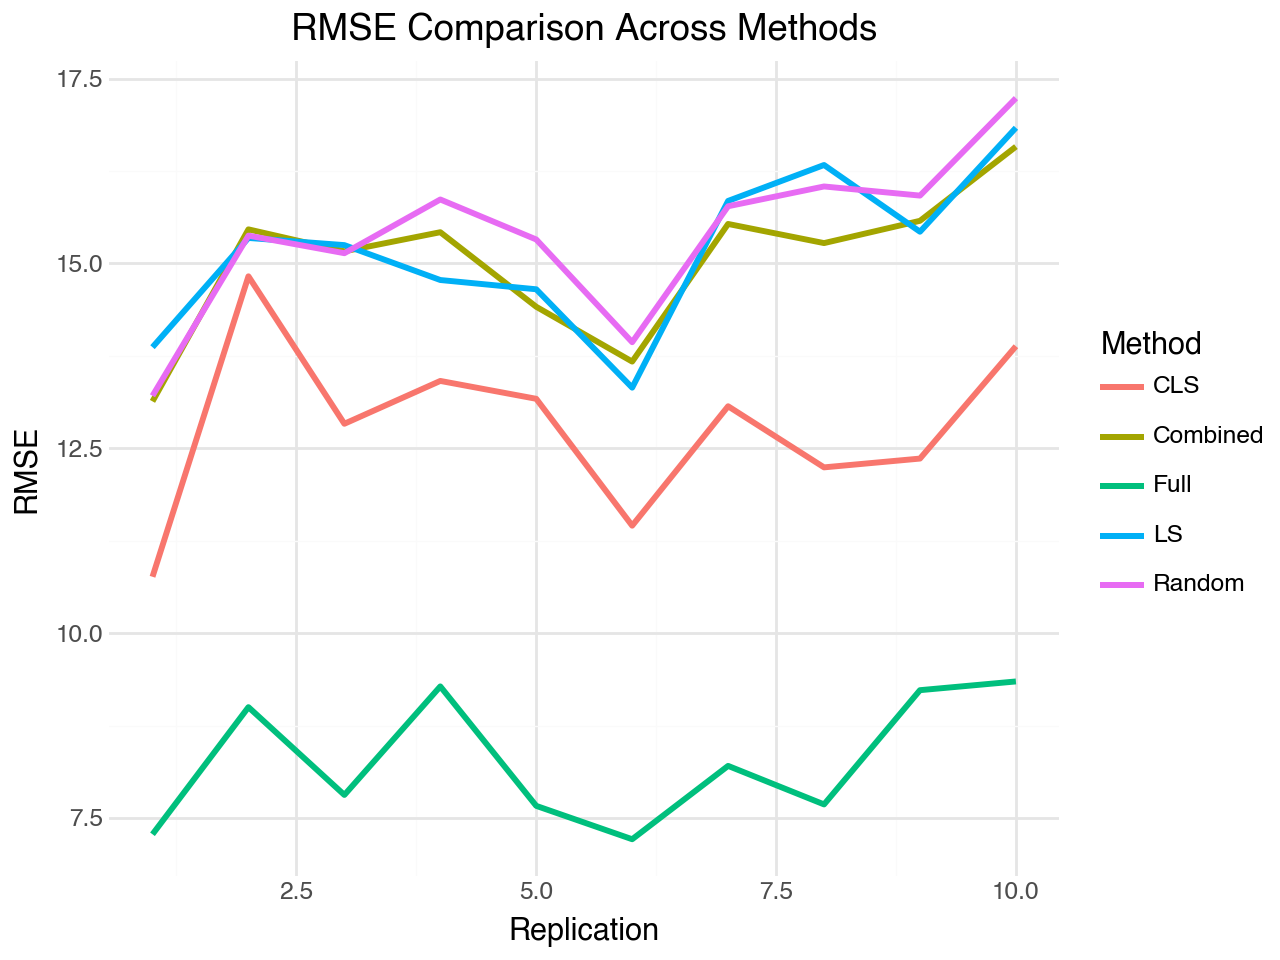

In [166]:
#==============================================================================================
# RMSE Plotting: Building a Line Chart over the RMSE values by Replication
#==============================================================================================

# Index = Replication
rmse_df["Replication"] = np.arange(1, len(rmse_ls) + 1)

# crete long format
rmse_long = rmse_df.melt(
    id_vars="Replication",
    var_name="Method",
    value_name="RMSE"
)
p_line = (
    ggplot(rmse_long, aes(x="Replication", y="RMSE", color="Method"))
    + geom_line(size=1.2)
    + theme_minimal()
    + labs(
        title="RMSE Comparison Across Methods",
        x="Replication",
        y="RMSE"
    )
)
display(p_line)


In [156]:
#### LS Investigation
beta = beta_train[0]
beta = beta.to_numpy().reshape(-1)
ls = column_ls[0]  
c = int(np.ceil(k * np.log(k)))
top_c_indices = np.argsort(ls)[-c:]
print(top_c_indices)
true_nonzero = np.where(beta != 0.0)[0]
print(true_nonzero)

hits = np.intersect1d(top_c_indices, true_nonzero)
print(f"Von den Top-{c} LS-Spalten sind {len(hits)} korrekt identifiziert")

[419 593 955 290 159 904 468 859 856 490 609 519 747 473 965 951 909 880
 318 460 466 610 590 366 247 903 479 687 445 831 120 196 853  87 320 446
 343  17  91 645 267   5 329 302 418  81 942 485 282 850 412 272 741  84
 898 363 122 166 843 341 686 350 885 568 620 491 703 971 649  60 498  46
 683 625 383 983 770 596 173 248  32  14 389 793 939 675  30 805 627  78
 254 987 356 513 353 325 380 526 842 371 532 806 873 634 525 896 334 443
 271 511 239 543 877 518  62 507 225 799 502 477 728 471 315 326 927 651
 779 742 914 628 374 104 913 961 578 876 564 137 358 727 973 682 554 404
 713 156 804 982 745 467 191 954 125 493 585 577 640 213 179 556 889 861
 886 106 390 976 953 364 327 655 740 160 351 136 461 574 522 822 891 163
 839 573 884 139 650 300   8 748 920 506 706 261 784 314 377  80]
[  3   6   9  12  13  19  22  23  25  27  42  54  58  60  75  79  83  88
  91 104 109 121 123 128 143 144 149 160 164 175 181 191 193 195 199 204
 206 218 219 221 224 226 227 232 250 256 267 268 271 272 2

In [157]:
#### CLS Investigation
cls = column_cls[0] 
c = int(np.ceil(k * np.log(k)))
top_c_indices = np.argsort(abs(cls))[-c:]
print(top_c_indices)
true_nonzero = np.where(beta != 0.0)[0]
print(beta[top_c_indices])

hits = np.intersect1d(top_c_indices, true_nonzero)
print(f"Von den Top-{c} CLS-Spalten sind {len(hits)} korrekt identifiziert")

tp = top_c_indices
print("Sum |beta| der gefundenen:")
print(np.sum(np.abs(beta[tp])))
print("Sum |beta|:")
print(np.sum(np.abs(beta)))

print("Max |beta| gefunden:")
print(np.max(np.abs(beta[tp])))
print("Max |beta|:")
print(np.max(np.abs(beta)))

[548  46 328 912 759   1 300 484 620 467  15 168 192 115 601  38 754 677
 454 491 633 636 813 775 930 935 730 851  66 960 380 295  60 447 347 968
 872 290  44 397 257 361 693 427  98 603 337 642 246 708 426 927  35 560
 792 945 353 373 251 437 501 705 393 679 100 680 406  23 204 567  13  12
 441 619 202 698 645 923  16 877 430 329 821 897  58 227 219 936 193 829
 540 575 131 824 253 688 327 809 224 873 419 191 741 990 602 630 869 175
  26  19 596 735 250 926 415 569 388 442 714 176  86 804 220 764  42 673
  22 343 148 855 815 282 794 463 822 496 617  34 771 846 996 725 893 959
 503 206 453 305 272 436 928 271 954  74 180 531 940 886 951 752 144 814
  88 122 464 625 268 720 848   6 875 899 368 618 350 423 611 913 652 623
 435 972 232 975 786 218 997 360 399 469 743 267 387 438 715 950]
[-0.17777854  0.          0.          0.03767764  0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.         -0.55676115  0.          0.          0.
  0.     

In [158]:
#### CS Investigation
cs = column_cs[0]  
c = int(np.ceil(k * np.log(k)))
top_c_indices = np.argsort(abs(cs))[-c:]
print(top_c_indices)
true_nonzero = np.where(beta != 0.0)[0]
print(true_nonzero)

hits = np.intersect1d(top_c_indices, true_nonzero)
print(f"Von den Top-{c} CS-Spalten sind {len(hits)} korrekt identifiziert")

[511 714 861  98 690 802 204 548 652 634 390 973 705 543 374 889 848 268
 928 526 842 923 175 987 176 253 686 361 727 546 959 315 914 869 930 940
  88 471 623 466 896 813 493 628 447 430 577  42 651 464 809 655  74 219
 351 565 806 439 503 574 106  14 181 926 794 640 556 745 747 724 404 500
 761 564 206 453 136 326 799 436 898 976 318 771 630 498 180 502 179 814
 968 567 805 358 961 156 139 815 364 748 899   8 290 463 983 779 627 573
 356 261 618 620  46 891 569 525 884 491 254 936 388  60 645 496 419 953
 611 650 329 706 461 213 125 380 920 554 531 423 725 585 975 875 752 353
 764 741 522 137   6 927 877 343 839 596 786 467 873 784 282 232 160 163
 218 399 272 951 740 314 360 720 368 997 506 191 122 271 804 300 972 327
 377  80 625 435 954 350 743 822 886 387 469 913 438 715 267 950]
[  3   6   9  12  13  19  22  23  25  27  42  54  58  60  75  79  83  88
  91 104 109 121 123 128 143 144 149 160 164 175 181 191 193 195 199 204
 206 218 219 221 224 226 227 232 250 256 267 268 271 272 2

In [159]:
#### RS Investigation
rs = column_rs[0]  
c = int(np.ceil(k * np.log(k)))
top_c_indices = np.argsort(rs)[-c:]
print(top_c_indices)
true_nonzero = np.where(beta != 0.0)[0]
print(true_nonzero)

hits = np.intersect1d(top_c_indices, true_nonzero)
print(f"Von den Top-{c} LS-Spalten sind {len(hits)} korrekt identifiziert")

[223 133 838 865 535 668 173 756 230 610 370 401 984 612 533 795 759 391
 253 444 495 602 526 939 754 321 296 738 687  55 874  18  57 999 386 993
  60 270 853 484 919 481 325 946 670 726 751 304 899 237 564  36 913 876
 816 504 179 811 707 517 755 657 898 817 556 456 395 559 135 198 836 524
 956 786 466 672 385 626 408 906 157 953 653 205 742 986 349 174 313 159
 547 478 880 616 227 113 267 134  25 279 577 277 881 199 476  16 571 377
 840 457 514 201 921 362 491 723 292 940 403 171 278 558 288 624 500 258
 153 440 566  70 704 396 761 620  63  51 282 663 989 319 226 997  80 882
 240 252 132 985 627 681 856 246 499 900 824 776 160 842  21 803  41   9
 421 392 180 228 890 333 703 725 427 851 352 814 788 968 908 202 316 715
 927 151 665 588 378  74 887 108 599  89 210  48 649 858 110 477]
[  3   6   9  12  13  19  22  23  25  27  42  54  58  60  75  79  83  88
  91 104 109 121 123 128 143 144 149 160 164 175 181 191 193 195 199 204
 206 218 219 221 224 226 227 232 250 256 267 268 271 272 2